Libraries Loaded Successfully

Dataset Path Found:
/kaggle/input/datasets/kavanacv/rq6-fraud-by-category/credit_card_frauds.csv

Dataset Loaded Successfully

Data Split Completed

Logistic Regression Accuracy:
0.9940961691351845

Random Forest Accuracy:
0.9953476046052825

Model Comparison Table:
                 Model  Accuracy
0  Logistic Regression  0.994096
1        Random Forest  0.995348


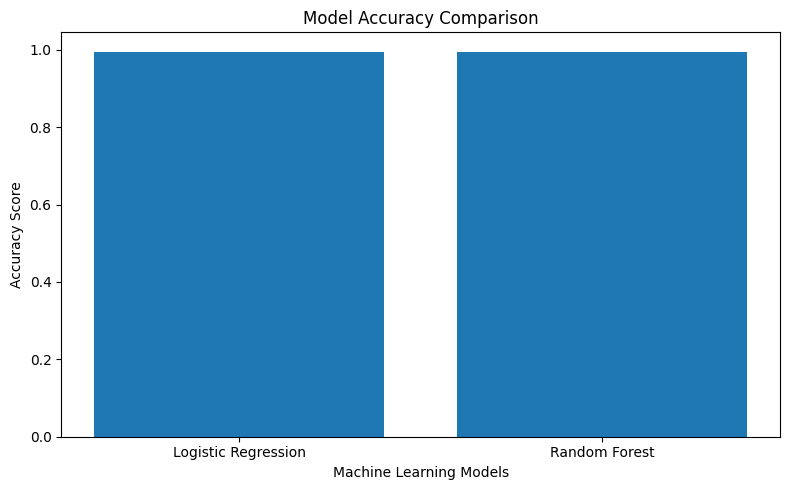


RQ7 Completed Successfully


In [1]:
# =========================================
# RQ7 - Model Comparison
# =========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Libraries Loaded Successfully")

# =========================================
# FIND DATASET AUTOMATICALLY
# =========================================

csv_path = ""

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_path = os.path.join(dirname, filename)

print("\nDataset Path Found:")
print(csv_path)

# =========================================
# LOAD DATASET
# =========================================

data = pd.read_csv(csv_path)

print("\nDataset Loaded Successfully")

# =========================================
# KEEP ONLY NUMERIC COLUMNS
# =========================================

data_numeric = data.select_dtypes(include=['int64', 'float64'])

# Features and Target
X = data_numeric.drop("is_fraud", axis=1)
y = data_numeric["is_fraud"]

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nData Split Completed")

# =========================================
# LOGISTIC REGRESSION
# =========================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("\nLogistic Regression Accuracy:")
print(lr_accuracy)

# =========================================
# RANDOM FOREST
# =========================================

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)

# =========================================
# COMPARISON TABLE
# =========================================

comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy]
})

print("\nModel Comparison Table:")
print(comparison_table)

# Save Table
comparison_table.to_csv(
    "RQ7_Model_Comparison.csv",
    index=False
)

# =========================================
# BAR GRAPH
# =========================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_table['Model'],
    comparison_table['Accuracy']
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")

plt.tight_layout()

# Save Figure
plt.savefig("RQ7_Model_Comparison.pdf")

plt.show()

print("\nRQ7 Completed Successfully")